## Parallel Flow
- Running multiple independent subtasks at once

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

API_KEY = os.getenv('AZURE_OPENAI_API_KEY')
BASE_URL = os.getenv('OPENAI_BASE_URL')

os.environ['LANGCHAIN_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ["LANGCHAIN_TRACING_V2"] = "true" # Enable LangSmith tracing
os.environ['LANGSMITH_PROJECT'] = 'LangGraphTraining' # Set the LangSmith project name

In [5]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

model = ChatOpenAI(
    api_key = API_KEY, 
    base_url= BASE_URL,
    model = 'gpt-5.1'
)

parser = StrOutputParser()

In [10]:
from typing import TypedDict, List, Dict, Optional
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

In [4]:
# Creating a stated graph
class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str

In [27]:
def generate_joke(state: State) -> State:
    prompt = PromptTemplate(template = 'Tell me a joke on this topic: {topic}')
    chain = prompt | model | parser
    state['joke'] = chain.invoke({'topic': state['topic']})
    # return state
    return {'joke': state['joke']}

def generate_story(state: State) -> State:
    prompt = PromptTemplate(template = 'Tell me a short story based on this topic: {topic}')
    chain = prompt | model | parser
    state['story'] = chain.invoke({'topic': state['topic']})
    # return state
    return {'story': state['story']}

def generate_poem(state: State) -> State:
    prompt = PromptTemplate(template = 'Write a short poem about this topic: {topic}')
    chain = prompt | model | parser
    state['poem'] = chain.invoke({'topic': state['topic']})
    # return state
    return {'poem': state['poem']}
    
def combine_outputs(state: State) -> State:
    state['combined_output'] = f"Joke: {state['joke']}\n\nStory: {state['story']}\n\nPoem: {state['poem']}"
    return state

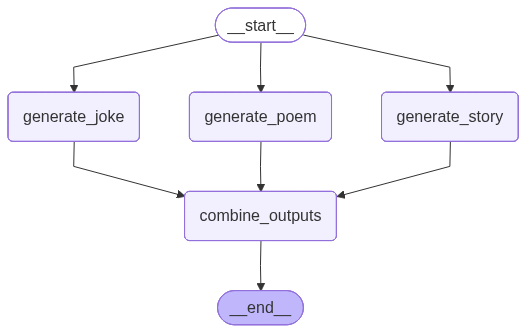

In [28]:
parallel_builder = StateGraph(State)

# Adding Nodes
parallel_builder.add_node('generate_joke', generate_joke)
parallel_builder.add_node('generate_story', generate_story)
parallel_builder.add_node('generate_poem', generate_poem)
parallel_builder.add_node('combine_outputs', combine_outputs)

# Adding edges
parallel_builder.add_edge(START, 'generate_joke')
parallel_builder.add_edge(START, 'generate_poem')
parallel_builder.add_edge(START, 'generate_story')
parallel_builder.add_edge('generate_story', 'combine_outputs')
parallel_builder.add_edge('generate_joke', 'combine_outputs')
parallel_builder.add_edge('generate_poem', 'combine_outputs')
parallel_builder.add_edge('combine_outputs', END)

graph = parallel_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [29]:
initial_state = State({'topic': 'Starks'})
final_state = graph.invoke(initial_state)
print(final_state['combined_output'])

Joke: Why don’t the Starks ever play hide and seek?

Because good luck hiding when everyone keeps yelling, “Winter is coming!”

Story: Snow fell like ash over Winterfell.

Arya Stark stood on the battlements, cheeks raw from the cold, Needle at her hip. Below her, the courtyard glowed with torchlight. Men sharpened swords, checked bowstrings, spoke in low voices of a night that might never end.

“Thinking of running?” Jon’s voice sounded behind her, rough with exhaustion, familiar as home.

She didn’t turn. “I’ve already done my running,” she said. “All the way to the other side of the world and back.”

He came to stand beside her. His cloak was black, but the direwolf was stitched in white across his chest now—Stark, whether he believed it or not.

“You remember the first time it snowed?” Jon asked. “We tried to catch flakes on our tongues and Bran fell off the wall trying to reach the highest one.”

Arya’s mouth twitched. “Father made him stay inside for a week, and he swore he’d cli